In [42]:
# Konfigurační blok: připojení Google Drivu a nastavení pracovního adresáře pro závěrečný projekt

from google.colab import drive
import os

# Připojení Google Drivu
drive.mount('/content/drive')

# Cesta k projektové složce
project_path = "/content/drive/MyDrive/Colab Notebooks/Vis - závěrečný projekt"

# Kontrola existence složky a případná změna pracovního adresáře
if os.path.isdir(project_path):
    os.chdir(project_path)
    print("Pracovní adresář nastaven na:", os.getcwd())
else:
    print("Upozornění: složka", project_path, "neexistuje – upravte proměnnou project_path podle umístění souborů.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pracovní adresář nastaven na: /content/drive/MyDrive/Colab Notebooks/Vis - závěrečný projekt


In [43]:
# Konfigurační blok: instalace knihovny Dash (ostatní knihovny jsou v Colabu obvykle předinstalované)

!pip install -q dash

In [44]:
# Konfigurační blok: import všech knihoven potřebných pro projekt covid_19_tracker

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.graph_objs as go
import plotly.express as px

from dash import Dash, dcc, html
from dash.dependencies import Input, Output

import threading
from google.colab import output

print(
    "Načtené knihovny:",
    "\n - pandas",
    "\n - seaborn",
    "\n - matplotlib.pyplot",
    "\n - plotly (graph_objs, express)",
    "\n - dash (Dash, dcc, html, Input, Output)",
    "\n - threading",
    "\n - google.colab.output"
)

Načtené knihovny: 
 - pandas 
 - seaborn 
 - matplotlib.pyplot 
 - plotly (graph_objs, express) 
 - dash (Dash, dcc, html, Input, Output) 
 - threading 
 - google.colab.output


In [45]:
# Konfigurační blok: aktualizace cesty k projektové složce
# POZNÁMKA: Oproti předchozímu kroku byla změněna cesta k projektu podle reálného umístění na Google Drivu.

from google.colab import drive
import os

# Připojení Google Drivu (pokud už je připojený, Colab to jen připomene)
drive.mount('/content/drive')

# Aktualizovaná cesta
project_path = "/content/drive/MyDrive/Colab Notebooks/Vis - závěrečný projekt"

# Kontrola existence složky a nastavení pracovního adresáře
if os.path.isdir(project_path):
    os.chdir(project_path)
    print("Pracovní adresář nastaven na:", os.getcwd())
else:
    print("Upozornění: složka", project_path, "neexistuje – zkontrolujte prosím cestu.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pracovní adresář nastaven na: /content/drive/MyDrive/Colab Notebooks/Vis - závěrečný projekt


Poznámka k nastavení pracovní cesty

Krok výše slouží k tomu, aby nebylo nutné v každém dalším importu nebo exportu používat kompletní absolutní cestu k souborům. Pokud bychom pracovní adresář nenastavili, bylo by nutné u každého načtení dat, obrázků nebo exportu grafů uvádět celou cestu, což vede k méně přehlednému a hůře udržovatelnému kódu. Nastavení adresáře proto zvyšuje profesionalitu a čistotu projektu.

In [46]:
# Import dat z CSV souboru pomocí knihovny pandas

import pandas as pd

# Název souboru – UPRAVTE, pokud máte jiný název CSV souboru
file_name = "project_1_python.csv"
file_path = os.path.join(project_path, file_name)

try:
    # Načtení CSV do DataFrame
    df = pd.read_csv(file_path)

    # Základní informace o datovém rámci
    print("Soubor byl úspěšně načten.")
    print("--------------------------------------------------")
    print("Počet řádků a sloupců:", df.shape)
    print("--------------------------------------------------")
    print("Prvních 5 řádků dat:")
    display(df.head())
except FileNotFoundError:
    print(f"Chyba: Soubor '{file_name}' nebyl nalezen v cestě:\n{file_path}")
except Exception as e:
    print("Při načítání souboru došlo k chybě:")
    print(e)


Soubor byl úspěšně načten.
--------------------------------------------------
Počet řádků a sloupců: (180477, 24)
--------------------------------------------------
Prvních 5 řádků dat:


,index,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,hosp_patients,...,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,population,median_age,gdp_per_capita,life_expectancy,latitude,longitude
0,0,AFG,Asia,Afghanistan,2020-02-24,5.0,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
1,1,AFG,Asia,Afghanistan,2020-02-25,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
2,2,AFG,Asia,Afghanistan,2020-02-26,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
3,3,AFG,Asia,Afghanistan,2020-02-27,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
4,4,AFG,Asia,Afghanistan,2020-02-28,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0


In [47]:
# Kontrola úplnosti a základní kvality dat ve vytvořeném DataFrame

print("ZÁKLADNÍ INFORMACE O DATAFRAME")
print("--------------------------------------------------")
df_info = df.info()  # tiskne přehled do výstupu
print("--------------------------------------------------")

# Počet chybějících hodnot v jednotlivých sloupcích
na_counts = df.isna().sum()
na_percent = (na_counts / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_values": na_counts,
    "missing_percent": na_percent.round(2)
}).sort_values("missing_values", ascending=False)

print("PŘEHLED CHYBĚJÍCÍCH HODNOT (NA) PODLE SLOUPCŮ")
display(missing_df)

# Kontrola duplicitních řádků
duplicate_rows = df.duplicated().sum()
print("--------------------------------------------------")
print(f"Počet duplicitních řádků v datasetu: {duplicate_rows}")

# Souhrnný výpis "co všechno bylo provedeno"
print("\nSouhrn provedených kroků:")
print("1) Nastaven pracovní adresář na složku s projektem na Google Drivu.")
print("2) Načten CSV soubor do pandas DataFrame (df).")
print("3) Zobrazeny základní informace o df (počet řádků/sloupců, datové typy).")
print("4) Vypočten a zobrazen počet a procento chybějících hodnot v každém sloupci.")
print("5) Zjištěn počet duplicitních řádků v datasetu.")


ZÁKLADNÍ INFORMACE O DATAFRAME
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180477 entries, 0 to 180476
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   index                    180477 non-null  int64  
 1   iso_code                 180477 non-null  object 
 2   continent                180477 non-null  object 
 3   location                 180477 non-null  object 
 4   date                     180477 non-null  object 
 5   total_cases              173493 non-null  float64
 6   new_cases                173212 non-null  float64
 7   total_deaths             155323 non-null  float64
 8   new_deaths               155095 non-null  float64
 9   hosp_patients            27152 non-null   float64
 10  total_tests              78326 non-null   float64
 11  new_tests                74509 non-null   float64
 12  tests_per_case           92600 n

,missing_values,missing_percent
total_boosters,160611,88.99
hosp_patients,153325,84.96
new_vaccinations,143537,79.53
people_fully_vaccinated,138953,76.99
people_vaccinated,136626,75.70
total_vaccinations,134111,74.31
new_tests,105968,58.72
total_tests,102151,56.60
tests_per_case,87877,48.69
new_deaths,25382,14.06


--------------------------------------------------
Počet duplicitních řádků v datasetu: 0

Souhrn provedených kroků:
1) Nastaven pracovní adresář na složku s projektem na Google Drivu.
2) Načten CSV soubor do pandas DataFrame (df).
3) Zobrazeny základní informace o df (počet řádků/sloupců, datové typy).
4) Vypočten a zobrazen počet a procento chybějících hodnot v každém sloupci.
5) Zjištěn počet duplicitních řádků v datasetu.


In [48]:
# Výpočet 10 zemí s největší populací v datasetu
# POZNÁMKA: U některých zemí se může populace opakovat v různých řádcích, proto použijeme groupby + max.

# Výběr sloupců a odstranění chybějících populací
population_by_country = (
    df[['location', 'population']]
    .dropna(subset=['population'])
    .drop_duplicates()
    .groupby('location', as_index=False)['population']
    .max()
)

# Seřazení podle populace a výběr top 10
top10_population = (
    population_by_country
    .sort_values('population', ascending=False)
    .head(10)
)

print("10 zemí s největší populací v datasetu:")
display(top10_population)

# Identifikace země s nejvyšší a nejnižší populací v rámci TOP10
max_row = top10_population.loc[top10_population['population'].idxmax()]
min_row = top10_population.loc[top10_population['population'].idxmin()]

print("Souhrnná informace k populaci v TOP10:")
print(f"- Největší populaci z TOP10 má: {max_row['location']} ({max_row['population']:.0f} obyvatel).")
print(f"- Nejmenší populaci z TOP10 má: {min_row['location']} ({min_row['population']:.0f} obyvatel).")

print("\nSouhrn provedených kroků:")
print("1) Z původního DataFrame df byl vybrán sloupec location a population.")
print("2) Byly odstraněny chybějící hodnoty populace a duplicitní řádky.")
print("3) Byla spočtena maximální populace pro každou zemi (groupby).")
print("4) Dataset byl seřazen podle populace a vybráno 10 zemí s nejvyšší populací.")
print("5) V rámci TOP10 byla určena země s nejvyšší a nejnižší populací.")


10 zemí s největší populací v datasetu:


,location,population
40,China,1.444216e+09
90,India,1.393409e+09
213,United States,3.329151e+08
91,Indonesia,2.763618e+08
151,Pakistan,2.251999e+08
26,Brazil,2.139934e+08
144,Nigeria,2.114007e+08
15,Bangladesh,1.663035e+08
165,Russia,1.459120e+08
126,Mexico,1.302622e+08


Souhrnná informace k populaci v TOP10:
- Největší populaci z TOP10 má: China (1444216102 obyvatel).
- Nejmenší populaci z TOP10 má: Mexico (130262220 obyvatel).

Souhrn provedených kroků:
1) Z původního DataFrame df byl vybrán sloupec location a population.
2) Byly odstraněny chybějící hodnoty populace a duplicitní řádky.
3) Byla spočtena maximální populace pro každou zemi (groupby).
4) Dataset byl seřazen podle populace a vybráno 10 zemí s nejvyšší populací.
5) V rámci TOP10 byla určena země s nejvyšší a nejnižší populací.


/tmp/ipython-input-3087896075.py:30: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



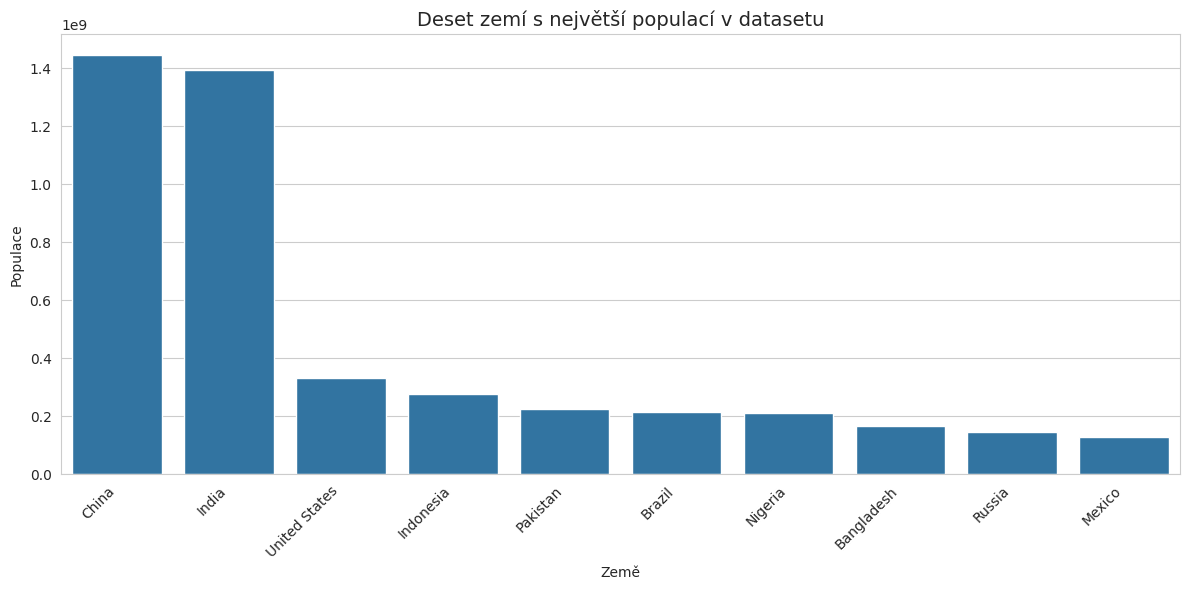

Souhrn provedených kroků k vizualizaci:
1) Nastaven styl seaborn na 'whitegrid'.
2) Vytvořen sloupcový graf s větší velikostí obrázku (12x6).
3) Osa X je seřazena podle populace a popisky jsou natočeny o 45°, aby se nepřekrývaly.


In [49]:
# Vytvoření sloupcového grafu pro 10 zemí s největší populací
# POZNÁMKA: Používáme seaborn styl 'whitegrid', větší figure size a rotaci popisků na ose X
#           tak, aby se texty nepřekrývaly.

import seaborn as sns
import matplotlib.pyplot as plt

# Nastavení stylu
sns.set_style("whitegrid")

# Vytvoření obrázku ve větším rozměru kvůli čitelnosti
plt.figure(figsize=(12, 6))

# Aby byl graf přehledný, seřadíme země podle populace sestupně i na ose X
order_countries = top10_population.sort_values('population', ascending=False)['location']

ax = sns.barplot(
    data=top10_population,
    x='location',
    y='population',
    order=order_countries
)

# Popisky a název grafu
ax.set_title('Deset zemí s největší populací v datasetu', fontsize=14)
ax.set_xlabel('Země')
ax.set_ylabel('Populace')

# Otočení popisků osy X, aby se nepřekrývaly
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Souhrn provedených kroků k vizualizaci:")
print("1) Nastaven styl seaborn na 'whitegrid'.")
print("2) Vytvořen sloupcový graf s větší velikostí obrázku (12x6).")
print("3) Osa X je seřazena podle populace a popisky jsou natočeny o 45°, aby se nepřekrývaly.")


In [50]:
# Příprava dat pro vizualizaci vztahu mezi populací a délkou života
# POZNÁMKA: Pro každou zemi používáme poslední dostupné datum,
#           aby byla v grafu každá země právě jednou.
# Vypnutí automaticky generovaných grafů v Google Colab

import pandas as pd

pd.options.display.html.table_schema = False
pd.options.display.html.use_mathjax = False  # volitelné, vypne matematický rendering

# Výběr relevantních sloupců a odstranění chybějících hodnot
cols = ['location', 'continent', 'date', 'population', 'life_expectancy']
df_life = (
    df[cols]
    .dropna(subset=['population', 'life_expectancy', 'continent'])
)

# Převod sloupce 'date' na typ datetime (pro jistotu, kdyby nebyl)
df_life['date'] = pd.to_datetime(df_life['date'])

# Pro každou zemi vybereme poslední záznam podle data
df_latest = (
    df_life.sort_values('date')
           .groupby('location', as_index=False)
           .tail(1)
)

print("Počet zemí v přehledu:", len(df_latest))
display(df_latest.head())

print("\nSouhrn provedených kroků (příprava dat):")
print("1) Z původního DataFrame df byly vybrány sloupce: location, continent, date, population, life_expectancy.")
print("2) Odstraněny záznamy s chybějící populací, délkou života nebo kontinentem.")
print("3) Sloupec 'date' byl převeden na typ datetime.")
print("4) Pro každou zemi byl vybrán poslední dostupný záznam (nejnovější datum).")


Počet zemí v přehledu: 223


,location,continent,date,population,life_expectancy
163110,Tokelau,Oceania,2021-10-12,1368.0,81.86
121306,Northern Mariana Islands,Oceania,2021-12-04,57910.0,76.74
166401,Turkmenistan,Asia,2022-03-06,6117933.0,68.19
119241,Niue,Oceania,2022-03-13,1614.0,73.71
167558,Tuvalu,Oceania,2022-04-05,11925.0,67.57



Souhrn provedených kroků (příprava dat):
1) Z původního DataFrame df byly vybrány sloupce: location, continent, date, population, life_expectancy.
2) Odstraněny záznamy s chybějící populací, délkou života nebo kontinentem.
3) Sloupec 'date' byl převeden na typ datetime.
4) Pro každou zemi byl vybrán poslední dostupný záznam (nejnovější datum).


In [51]:
# Vytvoření interaktivní plotly vizualizace:
# vztah mezi populací (osa X, logaritmická) a délkou života (osa Y),
# barvy bodů podle kontinentu s jinou paletou než výchozí.

import plotly.express as px

# Využijeme jinou barevnou paletu než výchozí (např. Set2)
color_palette = px.colors.qualitative.Set2

fig = px.scatter(
    df_latest,
    x='population',
    y='life_expectancy',
    color='continent',
    hover_name='location',
    hover_data={'population': ':,.0f', 'life_expectancy': ':.1f', 'continent': True},
    log_x=True,  # logaritmické měřítko na ose X
    color_discrete_sequence=color_palette,
    title='Vztah mezi populací a očekávanou délkou života podle zemí'
)

# Úprava popisků os
fig.update_layout(
    xaxis_title='Populace (logaritmická stupnice)',
    yaxis_title='Očekávaná délka života (roky)',
    legend_title_text='Kontinent'
)

fig.show()

print("Souhrn provedených kroků (vizualizace):")
print("1) Vytvořen scatter plot pomocí plotly.express se zeměmi jako body.")
print("2) Osa X nastavena na logaritmické měřítko (log_x=True).")
print("3) Barva bodů určena kontinentem, použita jiná barevná paleta než výchozí (Set2).")
print("4) Doplněn název grafu a popisky os včetně popisu logaritmické stupnice.")


Souhrn provedených kroků (vizualizace):
1) Vytvořen scatter plot pomocí plotly.express se zeměmi jako body.
2) Osa X nastavena na logaritmické měřítko (log_x=True).
3) Barva bodů určena kontinentem, použita jiná barevná paleta než výchozí (Set2).
4) Doplněn název grafu a popisky os včetně popisu logaritmické stupnice.


In [52]:
# Vylepšený kód navíc k vizualizaci "Populace vs. délka života"
# Kombinuje přípravu dat a vykreslení grafu s estetickými vylepšeními.

import pandas as pd
import plotly.express as px

# -----------------------------
# 1) PŘÍPRAVA DAT
# -----------------------------

cols = ['location', 'continent', 'date', 'population', 'life_expectancy']

# výběr relevantních sloupců a odstranění chybějících hodnot
df_life = (
    df[cols]
    .dropna(subset=['population', 'life_expectancy', 'continent'])
)

# převod data na datetime
df_life['date'] = pd.to_datetime(df_life['date'])

# pro každou zemi vybereme poslední dostupný záznam
df_latest = (
    df_life
    .sort_values('date')
    .groupby('location', as_index=False)
    .tail(1)
)

print("Počet zemí v přehledu:", len(df_latest))

# -----------------------------
# 2) VYLEPŠENÁ VIZUALIZACE
# -----------------------------

color_palette = px.colors.qualitative.Set2

fig = px.scatter(
    df_latest,
    x='population',
    y='life_expectancy',
    color='continent',
    hover_name='location',
    hover_data={
        'population': ':,.0f',
        'life_expectancy': ':.1f',
        'continent': True
    },
    log_x=True,
    color_discrete_sequence=color_palette,
    title='Vztah mezi populací a očekávanou délkou života podle zemí'
)

# větší body, průhlednost a obrys
fig.update_traces(
    marker=dict(
        size=9,
        opacity=0.7,
        line=dict(width=0.3, color='black')
    )
)

# čistý vzhled, popisky os, horizontální legenda
fig.update_layout(
    template='simple_white',
    xaxis_title='Populace (logaritmická stupnice)',
    yaxis_title='Očekávaná délka života (roky)',
    legend_title_text='Kontinent',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

fig.show()

# -----------------------------
# 3) SOUHRN
# -----------------------------
summary = """
Souhrn provedených kroků (vylepšená verze):
1) Z původního DataFrame df byly vybrány sloupce: location, continent, date, population, life_expectancy.
2) Odstraněny záznamy s chybějící populací, délkou života nebo kontinentem a datum převedeno na typ datetime.
3) Pro každou zemi byl vybrán poslední dostupný záznam (nejnovější datum).
4) Pomocí plotly.express byl vytvořen scatter plot s logaritmickou osou X a barvami podle kontinentu.
5) Graf byl vizuálně vylepšen: větší a částečně průhledné značky s obrysem, čistý vzhled ('simple_white'),
   upravená legenda a popisky os pro lepší čitelnost.
"""
print(summary)


Počet zemí v přehledu: 223



Souhrn provedených kroků (vylepšená verze):
1) Z původního DataFrame df byly vybrány sloupce: location, continent, date, population, life_expectancy.
2) Odstraněny záznamy s chybějící populací, délkou života nebo kontinentem a datum převedeno na typ datetime.
3) Pro každou zemi byl vybrán poslední dostupný záznam (nejnovější datum).
4) Pomocí plotly.express byl vytvořen scatter plot s logaritmickou osou X a barvami podle kontinentu.
5) Graf byl vizuálně vylepšen: větší a částečně průhledné značky s obrysem, čistý vzhled ('simple_white'),
   upravená legenda a popisky os pro lepší čitelnost.



In [53]:
# Vizualizace počtu nově diagnostikovaných případů COVID-19 v čase
# Porovnání dvou evropských zemí s podobnou populací: Sweden vs Portugal

import pandas as pd
import plotly.express as px

# -----------------------------
# 1) PŘÍPRAVA DAT
# -----------------------------

# Definice dvojice zemí
countries = ["Sweden", "Portugal"]

# Výběr potřebných sloupců a filtrování na dvě zvolené země
df_cases = (
    df[["location", "date", "new_cases"]]
    .loc[df["location"].isin(countries)]
    .copy()
)

# Převod data na datetime a seřazení pro správné vykreslení časové řady
df_cases["date"] = pd.to_datetime(df_cases["date"])
df_cases = df_cases.sort_values(["location", "date"])

print("Počet řádků pro zvolené země:", len(df_cases))
print("Rozsah dat:", df_cases["date"].min().date(), "→", df_cases["date"].max().date())

# -----------------------------
# 2) VIZUALIZACE – ZÁKLADNÍ VERZE
# -----------------------------

# Využijeme jinou kvalitativní paletu než výchozí (např. Set1)
color_palette = px.colors.qualitative.Set1

fig = px.line(
    df_cases,
    x="date",
    y="new_cases",
    color="location",
    color_discrete_sequence=color_palette,
    hover_name="location",
    hover_data={
        "date": True,
        "new_cases": ":,.0f",
        "location": False
    },
    title="Počet nově diagnostikovaných případů COVID-19: Sweden vs Portugal"
)

# Úprava vzhledu grafu
fig.update_layout(
    template="simple_white",
    xaxis_title="Datum",
    yaxis_title="Počet nových případů (denní hodnota)",
    legend_title_text="Země"
)

fig.show()

# -----------------------------
# 3) SOUHRN
# -----------------------------
summary = """
Souhrn provedených kroků (Sweden vs Portugal – nové případy):
1) Z původního DataFrame df byly vybrány sloupce: location, date, new_cases.
2) Data byla vyfiltrována pouze pro země Sweden a Portugal.
3) Sloupec 'date' byl převeden na typ datetime a data byla seřazena podle země a data.
4) Pomocí plotly.express byl vytvořen čárový graf (line chart), kde osa X představuje datum
   a osa Y počet nově diagnostikovaných případů COVID-19.
5) Barva čáry je určena zemí, byla použita jiná barevná paleta než výchozí (Set1),
   doplněn název grafu a popisky os pro přehlednou interpretaci.
"""
print(summary)


Počet řádků pro zvolené země: 1709
Rozsah dat: 2020-02-01 → 2022-06-18



Souhrn provedených kroků (Sweden vs Portugal – nové případy):
1) Z původního DataFrame df byly vybrány sloupce: location, date, new_cases.
2) Data byla vyfiltrována pouze pro země Sweden a Portugal.
3) Sloupec 'date' byl převeden na typ datetime a data byla seřazena podle země a data.
4) Pomocí plotly.express byl vytvořen čárový graf (line chart), kde osa X představuje datum
   a osa Y počet nově diagnostikovaných případů COVID-19.
5) Barva čáry je určena zemí, byla použita jiná barevná paleta než výchozí (Set1),
   doplněn název grafu a popisky os pro přehlednou interpretaci.



In [54]:
# Vylepšená A+ verze: 7denní klouzavý průměr nových případů

df_cases_smooth = df_cases.copy()

# Výpočet 7denního klouzavého průměru pro každou zemi zvlášť
df_cases_smooth["new_cases_7d"] = (
    df_cases_smooth
    .groupby("location")["new_cases"]
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

fig_smooth = px.line(
    df_cases_smooth,
    x="date",
    y="new_cases_7d",
    color="location",
    color_discrete_sequence=color_palette,
    hover_name="location",
    hover_data={
        "date": True,
        "new_cases_7d": ":,.0f",
        "location": False
    },
    title="7denní klouzavý průměr nových případů COVID-19: Sweden vs Portugal"
)

fig_smooth.update_layout(
    template="simple_white",
    xaxis_title="Datum",
    yaxis_title="Počet nových případů (7denní klouzavý průměr)",
    legend_title_text="Země"
)

fig_smooth.show()

print(
    "Souhrn (A+ verze):\n"
    "1) Na základě denních hodnot nových případů byl pro každou zemi spočten 7denní klouzavý průměr.\n"
    "2) Byla vytvořena druhá časová řada, která lépe ukazuje průběh jednotlivých vln pandemie\n"
    "   a omezuje vliv denních výkyvů a víkendových efektů."
)


Souhrn (A+ verze):
1) Na základě denních hodnot nových případů byl pro každou zemi spočten 7denní klouzavý průměr.
2) Byla vytvořena druhá časová řada, která lépe ukazuje průběh jednotlivých vln pandemie
   a omezuje vliv denních výkyvů a víkendových efektů.


Interpretace výsledků (Sweden vs Portugal – denní případy + 7denní klouzavý průměr)
1. Srovnání dynamiky pandemie

Obě země mají podobnou populaci (~10 milionů), ale průběh pandemie se výrazně liší.

Portugalsko vykazuje vyšší „špičky“ ve více obdobích, zejména během zimních vln.

Švédsko má naopak během většiny roku mírnější průběh, s nejvýraznější vlnou až při šíření varianty omikron (konec 2021 – začátek 2022).

2. Vliv strategie a sezónnosti

Portugalsko mělo přísnější protiepidemická opatření a vyšší proočkovanost, přesto ale docházelo k výrazným zimním nárůstům.

Švédsko s volnějším přístupem mělo plošnější, stabilnější průběh bez extrémních skoků (vyjma omikronu).

Výrazné sezónní chování je patrné u obou zemí — maxima pandemie se soustředí zejména do zimních měsíců.

3. Co ukazuje 7denní klouzavý průměr

Klouzavý průměr eliminuje víkendové výkyvy, takže jasně odhaluje tvar jednotlivých vln.

Portugalsko má 3–4 velmi výrazné vrcholy, které přesahují i 60 000 případů denně.

Švédsko má hlavní vrchol pouze jeden: omikron na začátku 2022, který dominuje celému průběhu.

4. Shrnutí

Pandemie se v obou zemích ubírala odlišnou cestou navzdory podobné velikosti populace.

Klimatické, geografické a strategické rozdíly se v grafech projevují velmi výrazně.

Obě vizualizace umožňují porovnat dopady různých přístupů k řízení pandemie i různé časové profily jednotlivých vln.

Ačkoli mají Švédsko a Portugalsko téměř stejný počet obyvatel, průběh pandemie se u nich výrazně lišil. Portugalsko zažilo několik prudkých vln s vysokými denními počty případů, zatímco Švédsko mělo spíše pozvolný, stabilnější průběh až do nástupu omikronu. Graf tak ukazuje, že strategické a společenské rozdíly měly na dynamiku pandemie větší dopad než samotná velikost populace.

In [55]:
# Mapa COVID-19 – podíl populace nakažené v jednotlivých zemích
# Vizuál: Plotly scatter_mapbox, barvy podle kontinentu, velikost markeru podle % populace nakažené COVID-19.

import pandas as pd
import plotly.express as px

# -------------------------------------------------------------------
# 1) NASTAVENÍ MAPBOX TOKENU (NUTNÉ PRO ZOBRAZENÍ MAPY)
# -------------------------------------------------------------------
# POZNÁMKA: Zde vložte svůj Mapbox Access Token, který jste používali během kurzu.
# Pokud token nemáte, vytvořte si ho v Mapbox účtu a nahraďte text 'YOUR_MAPBOX_TOKEN_HERE'.

px.set_mapbox_access_token("YOUR_MAPBOX_TOKEN_HERE")  # <-- ZMĚŇTE NA VLASTNÍ TOKEN

# -------------------------------------------------------------------
# 2) PŘÍPRAVA DAT PRO MAPU
# -------------------------------------------------------------------

# Výběr potřebných sloupců
cols = ['location', 'continent', 'date', 'total_cases', 'population', 'latitude', 'longitude']
df_map = df[cols].copy()

# Odstranění záznamů bez kontinentu, bez počtu případů, bez populace nebo bez souřadnic
df_map = df_map.dropna(subset=['continent', 'total_cases', 'population', 'latitude', 'longitude'])

# Převod data na datetime a seřazení
df_map['date'] = pd.to_datetime(df_map['date'])
df_map = df_map.sort_values(['location', 'date'])

# Pro každou zemi vybereme poslední dostupný záznam (nejnovější datum)
df_latest_map = df_map.groupby('location', as_index=False).tail(1)

# Výpočet procenta populace, která byla nakažena (total_cases / population * 100)
df_latest_map['cases_pct_population'] = (df_latest_map['total_cases'] / df_latest_map['population']) * 100

# Odstranění zemí bez nenulových případů (pro přehlednější mapu)
df_latest_map = df_latest_map[df_latest_map['total_cases'] > 0]

print("Počet zemí na mapě:", len(df_latest_map))

# -------------------------------------------------------------------
# 3) VIZUALIZACE – MAPA COVID-19
# -------------------------------------------------------------------

# Jiná barevná paleta než výchozí
color_palette = px.colors.qualitative.Set2

fig = px.scatter_mapbox(
    df_latest_map,
    lat='latitude',
    lon='longitude',
    size='cases_pct_population',              # velikost markeru podle % populace nakažené COVID-19
    color='continent',                        # barva podle kontinentu
    color_discrete_sequence=color_palette,
    hover_name='location',
    hover_data={
        'continent': True,
        'total_cases': ':,.0f',
        'population': ':,.0f',
        'cases_pct_population': ':.2f'
    },
    size_max=40,                              # maximální velikost značky kvůli čitelnosti
    zoom=1,                                   # počáteční přiblížení – celá mapa světa
    center={'lat': 20, 'lon': 0},             # mírně posunutý střed mapy
    title='Podíl populace nakažené COVID-19 podle zemí (barva = kontinent, velikost = % populace)'
)

# Tmavý styl mapy + úprava rozložení
fig.update_layout(
    mapbox_style='dark',
    margin=dict(l=0, r=0, t=60, b=0),
    legend_title_text='Kontinent'
)

fig.show()

# -------------------------------------------------------------------
# 4) SOUHRN
# -------------------------------------------------------------------
summary = """
Souhrn provedených kroků (Mapa COVID-19):
1) Z původního DataFrame df byly vybrány sloupce: location, continent, date, total_cases, population, latitude, longitude.
2) Byly odstraněny záznamy bez kontinentu, počtu případů, populace nebo souřadnic a pro každou zemi byl vybrán
   poslední dostupný záznam (nejnovější datum).
3) Pro každou zemi byl spočten podíl populace nakažené COVID-19 (total_cases / population * 100).
4) Pomocí plotly.express.scatter_mapbox byla vytvořena mapa světa, kde:
   - barva značky odpovídá kontinentu,
   - velikost značky závisí na procentu populace nakažené COVID-19,
   - počáteční přiblížení a střed mapy byly nastaveny tak, aby byla vidět celá mapa světa,
   - maximální velikost značky byla omezena kvůli čitelnosti.
5) Nastaven byl tmavý Mapbox styl a v popisku po najetí myší se zobrazuje název země,
   počet případů, populace a podíl nakažené populace.
"""
print(summary)


Počet zemí na mapě: 213


/tmp/ipython-input-376455904.py:34: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy




Souhrn provedených kroků (Mapa COVID-19):
1) Z původního DataFrame df byly vybrány sloupce: location, continent, date, total_cases, population, latitude, longitude.
2) Byly odstraněny záznamy bez kontinentu, počtu případů, populace nebo souřadnic a pro každou zemi byl vybrán
   poslední dostupný záznam (nejnovější datum).
3) Pro každou zemi byl spočten podíl populace nakažené COVID-19 (total_cases / population * 100).
4) Pomocí plotly.express.scatter_mapbox byla vytvořena mapa světa, kde:
   - barva značky odpovídá kontinentu,
   - velikost značky závisí na procentu populace nakažené COVID-19,
   - počáteční přiblížení a střed mapy byly nastaveny tak, aby byla vidět celá mapa světa,
   - maximální velikost značky byla omezena kvůli čitelnosti.
5) Nastaven byl tmavý Mapbox styl a v popisku po najetí myší se zobrazuje název země,
   počet případů, populace a podíl nakažené populace.



In [56]:
# Příprava dat pro mapu COVID-19 (společná pro Mapbox i bez Mapboxu)

import pandas as pd

cols = ['location', 'continent', 'date', 'total_cases', 'population', 'latitude', 'longitude']
df_map = df[cols].copy()

# Odstranění záznamů bez kontinentu, počtu případů, populace nebo souřadnic
df_map = df_map.dropna(subset=['continent', 'total_cases', 'population', 'latitude', 'longitude'])

# Převod data na datetime a seřazení
df_map['date'] = pd.to_datetime(df_map['date'])
df_map = df_map.sort_values(['location', 'date'])

# Pro každou zemi vybereme poslední dostupný záznam (nejnovější datum)
df_latest_map = df_map.groupby('location', as_index=False).tail(1)

# Výpočet procenta populace, která byla nakažena (total_cases / population * 100)
df_latest_map['cases_pct_population'] = (df_latest_map['total_cases'] / df_latest_map['population']) * 100

# Odstraníme země bez nenulových případů
df_latest_map = df_latest_map[df_latest_map['total_cases'] > 0]

print("Počet zemí na mapě:", len(df_latest_map))


Počet zemí na mapě: 213


/tmp/ipython-input-2751741612.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [57]:
# Widget pro vložení Mapbox tokenu – skryté zadávání (hvězdičky)
import ipywidgets as widgets
from IPython.display import display

mapbox_token_widget = widgets.Password(
    value='',
    placeholder='Sem vložte svůj Mapbox access token',
    description='Mapbox token:',
    style={'description_width': '110px'},
    layout=widgets.Layout(width='90%')
)

display(mapbox_token_widget)

print("Poznámka: Po vložení tokenu spusťte buňku s mapou. Token se načte z tohoto políčka a zůstane skryt.")

Password(description='Mapbox token:', layout=Layout(width='90%'), placeholder='Sem vložte svůj Mapbox access t…

Poznámka: Po vložení tokenu spusťte buňku s mapou. Token se načte z tohoto políčka a zůstane skryt.


In [ ]:
# Mapa COVID-19 s použitím Mapboxu – barva = kontinent, velikost = % populace nakažené COVID-19

import plotly.express as px

# Nastavení Mapbox tokenu z widgetu
if mapbox_token_widget.value:
    px.set_mapbox_access_token(mapbox_token_widget.value)
else:
    print("Upozornění: Mapbox token není vyplněn. Doplňte ho prosím do políčka nad touto buňkou.")
    # Mapa se i tak může zobrazit jen částečně nebo vůbec – záleží na prostředí.

color_palette = px.colors.qualitative.Set2

fig_mapbox = px.scatter_mapbox(
    df_latest_map,
    lat='latitude',
    lon='longitude',
    size='cases_pct_population',              # velikost markeru podle % populace nakažené COVID-19
    color='continent',                        # barva podle kontinentu
    color_discrete_sequence=color_palette,
    hover_name='location',
    hover_data={
        'continent': True,
        'total_cases': ':,.0f',
        'population': ':,.0f',
        'cases_pct_population': ':.2f'
    },
    size_max=40,                              # maximální velikost značky
    zoom=1,                                   # počáteční přiblížení – celá mapa světa
    center={'lat': 20, 'lon': 0},             # střed mapy
    title='Podíl populace nakažené COVID-19 podle zemí (Mapbox, tmavé pozadí)'
)

fig_mapbox.update_layout(
    mapbox_style='dark',
    margin=dict(l=0, r=0, t=60, b=0),
    legend_title_text='Kontinent'
)

fig_mapbox.show()

print(
    "Souhrn (Mapbox verze):\n"
    "1) Data byla agregována na úroveň zemí (poslední dostupný záznam, výpočet % nakažené populace).\n"
    "2) Pomocí scatter_mapbox byla vykreslena mapa světa s barvami podle kontinentu\n"
    "   a velikostí markerů dle podílu nakažené populace.\n"
    "3) Mapbox token je načítán z textového políčka nad touto buňkou, takže každý uživatel může použít vlastní token."
)


In [59]:
# Alternativní mapa COVID-19 bez Mapboxu – scatter_geo (nevyžaduje žádný token)

import plotly.express as px

color_palette = px.colors.qualitative.Set2

fig_geo = px.scatter_geo(
    df_latest_map,
    lat='latitude',
    lon='longitude',
    size='cases_pct_population',
    color='continent',
    color_discrete_sequence=color_palette,
    hover_name='location',
    hover_data={
        'continent': True,
        'total_cases': ':,.0f',
        'population': ':,.0f',
        'cases_pct_population': ':.2f'
    },
    size_max=30,
    projection='natural earth',
    title='Podíl populace nakažené COVID-19 podle zemí (bez Mapboxu)'
)

fig_geo.update_layout(
    template='plotly_dark',   # tmavší vzhled bez nutnosti Mapboxu
    legend_title_text='Kontinent',
    margin=dict(l=0, r=0, t=60, b=0)
)

fig_geo.show()

print(
    "Souhrn (verze bez Mapboxu):\n"
    "1) Použita byla stejná agregovaná data df_latest_map jako u Mapbox verze.\n"
    "2) Vizualizace využívá scatter_geo, který nevyžaduje Mapbox token.\n"
    "3) Barva bodů odpovídá kontinentu, velikost bodů podílu populace nakažené COVID-19.\n"
    "4) Šablona 'plotly_dark' simuluje tmavé pozadí mapy bez závislosti na externích dlaždicích."
)


Souhrn (verze bez Mapboxu):
1) Použita byla stejná agregovaná data df_latest_map jako u Mapbox verze.
2) Vizualizace využívá scatter_geo, který nevyžaduje Mapbox token.
3) Barva bodů odpovídá kontinentu, velikost bodů podílu populace nakažené COVID-19.
4) Šablona 'plotly_dark' simuluje tmavé pozadí mapy bez závislosti na externích dlaždicích.


Stručné shrnutí

Vizuální mapa ukazuje, jak se COVID-19 v jednotlivých zemích šířil v přepočtu na celkovou populaci. Velikost markeru vyjadřuje procento populace, která byla během pandemie nakažena, a barvy rozlišují kontinenty. Nejvyšší podíly nakažených jsou patrné zejména v Evropě a Jižní Americe, zatímco řada afrických a asijských zemí vykazuje výrazně nižší hodnoty. Mapa tak poskytuje rychlý a přehledný celosvětový pohled na relativní dopady pandemie v jednotlivých regionech.

In [60]:
# Příprava dat pro Dash dashboard (kumulativní případy a úmrtí podle zemí)

import pandas as pd

# Výběr potřebných sloupců
cols = ["location", "date", "total_cases", "total_deaths"]
df_dash = df[cols].copy()

# Odstranění řádků bez lokace
df_dash = df_dash.dropna(subset=["location"])

# Převod data na datetime
df_dash["date"] = pd.to_datetime(df_dash["date"])

# Seřazení podle země a data
df_dash = df_dash.sort_values(["location", "date"])

# Vymazání irelevantních nebo prázdných záznamů
df_dash = df_dash.dropna(subset=["total_cases", "total_deaths"], how="all")

# Výpis pro kontrolu
print("Počet řádků:", len(df_dash))
print("Počet unikátních zemí:", df_dash["location"].nunique())
df_dash.head()


Počet řádků: 173494
Počet unikátních zemí: 213


,location,date,total_cases,total_deaths
0,Afghanistan,2020-02-24,5.0,NaN
1,Afghanistan,2020-02-25,5.0,NaN
2,Afghanistan,2020-02-26,5.0,NaN
3,Afghanistan,2020-02-27,5.0,NaN
4,Afghanistan,2020-02-28,5.0,NaN


In [61]:
# Dash dashboard č. 1 – kumulativní počty případů a úmrtí na COVID-19 podle země
# Používá df_dash připravený výše (sloupce: location, date, total_cases, total_deaths)

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from google.colab import output
import threading

# 1) Seznam dostupných zemí
countries = sorted(df_dash["location"].unique())
default_country = "Czechia" if "Czechia" in countries else countries[0]

# 2) Inicializace aplikace Dash
app = dash.Dash(__name__)

app.layout = html.Div(
    [
        # Dynamický titulek závislý na vybrané zemi
        html.H1(
            id="dashboard-title",
            style={"textAlign": "center", "marginBottom": "20px"}
        ),

        # Dropdown filtr pro výběr země
        html.Div(
            [
                html.Label("Vyberte zemi:", htmlFor="country-dropdown"),
                dcc.Dropdown(
                    id="country-dropdown",
                    options=[{"label": c, "value": c} for c in countries],
                    value=default_country,
                    clearable=False,
                    style={"width": "60%"}
                ),
            ],
            style={"marginBottom": "30px"}
        ),

        # Graf kumulativního počtu případů
        dcc.Graph(id="cases-graph"),

        # Graf kumulativního počtu úmrtí
        dcc.Graph(id="deaths-graph"),
    ],
    style={"width": "80%", "margin": "0 auto"}
)

# 3) Callbacks – aktualizace titulku a obou grafů při změně vybrané země
@app.callback(
    [
        Output("dashboard-title", "children"),
        Output("cases-graph", "figure"),
        Output("deaths-graph", "figure"),
    ],
    Input("country-dropdown", "value"),
)
def update_dashboard(selected_country):
    # Filtrování dat pro vybranou zemi
    df_country = df_dash[df_dash["location"] == selected_country]

    # Titulek dashboardu
    title = f"Kumulativní počty případů a úmrtí na COVID-19 v zemi {selected_country}"

    # Graf kumulativních případů
    fig_cases = px.line(
        df_country,
        x="date",
        y="total_cases",
        template="simple_white",
        labels={"date": "Datum", "total_cases": "Kumulativní počet případů"},
    )
    fig_cases.update_traces(line=dict(width=2), marker=dict(size=0))
    fig_cases.update_layout(
        margin=dict(l=0, r=0, t=10, b=0),
        showlegend=False,
    )

    # Graf kumulativních úmrtí
    fig_deaths = px.line(
        df_country,
        x="date",
        y="total_deaths",
        template="simple_white",
        labels={"date": "Datum", "total_deaths": "Kumulativní počet úmrtí"},
    )
    fig_deaths.update_traces(line=dict(width=2), marker=dict(size=0))
    fig_deaths.update_layout(
        margin=dict(l=0, r=0, t=10, b=0),
        showlegend=False,
    )

    return title, fig_cases, fig_deaths


# 4) Spuštění aplikace v samostatném vlákně a otevření v nové záložce (Google Colab)
def run_app():
    app.run_server(host="0.0.0.0", port=8050, debug=False)


In [62]:
# Dash dashboard č. 1 – kumulativní počty případů a úmrtí na COVID-19 podle země
# Varianta 1: opravené řešení pro Google Colab (Dash 3 + iframe výstup)

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from google.colab import output
import threading

# ---------------- 1) Seznam zemí ----------------
countries = sorted(df_dash["location"].unique())
default_country = "Czechia" if "Czechia" in countries else countries[0]

# ---------------- 2) Aplikace Dash a layout ----------------
app = dash.Dash(__name__)

app.layout = html.Div(
    [
        html.H1(
            id="dashboard-title",
            style={"textAlign": "center", "marginBottom": "20px"}
        ),

        html.Div(
            [
                html.Label("Vyberte zemi:", htmlFor="country-dropdown"),
                dcc.Dropdown(
                    id="country-dropdown",
                    options=[{"label": c, "value": c} for c in countries],
                    value=default_country,
                    clearable=False,
                    style={"width": "60%"}
                ),
            ],
            style={"marginBottom": "30px"}
        ),

        # >>> dva grafy vedle sebe
        html.Div(
            [
                dcc.Graph(
                    id="cases-graph",
                    style={"width": "50%"}
                ),
                dcc.Graph(
                    id="deaths-graph",
                    style={"width": "50%"}
                ),
            ],
            style={"display": "flex", "flexDirection": "row"}
        ),
    ],
    style={"width": "80%", "margin": "0 auto"}
)

# ---------------- 3) Callbacks ----------------
@app.callback(
    [
        Output("dashboard-title", "children"),
        Output("cases-graph", "figure"),
        Output("deaths-graph", "figure"),
    ],
    Input("country-dropdown", "value"),
)
def update_dashboard(selected_country):
    df_country = df_dash[df_dash["location"] == selected_country]

    title = f"Kumulativní počty případů a úmrtí na COVID-19 v zemi {selected_country}"

    fig_cases = px.line(
        df_country,
        x="date",
        y="total_cases",
        template="simple_white",
        labels={"date": "Datum", "total_cases": "Kumulativní počet případů"},
    )
    fig_cases.update_traces(line=dict(width=2), marker=dict(size=0))
    fig_cases.update_layout(margin=dict(l=0, r=0, t=10, b=0), showlegend=False)

    fig_deaths = px.line(
        df_country,
        x="date",
        y="total_deaths",
        template="simple_white",
        labels={"date": "Datum", "total_deaths": "Kumulativní počet úmrtí"},
    )
    fig_deaths.update_traces(line=dict(width=2), marker=dict(size=0))
    fig_deaths.update_layout(margin=dict(l=0, r=0, t=10, b=0), showlegend=False)

    return title, fig_cases, fig_deaths


# ---------------- 4) Spuštění serveru ve vlákně + iframe v buňce ----------------
def run_app():
    # Dash 3: používáme app.run, ne app.run_server
    app.run(host="0.0.0.0", port=8050, debug=False, use_reloader=False)

thread = threading.Thread(target=run_app, daemon=True)
thread.start()

# Výstup přímo v buňce – iframe s dashboardem
output.serve_kernel_port_as_iframe(8050, height=800)

print(
    "Souhrn (Dash dashboard č. 1 – varianta 1):\n"
    "1) Z df_dash byla připravena data s kumulativními počty případů a úmrtí podle země a data.\n"
    "2) Pomocí dash a plotly byl vytvořen dashboard se dvěma spojnicovými grafy vedle sebe.\n"
    "3) Dropdown filtr umožňuje vybrat zemi; oba grafy i titulek se dynamicky mění.\n"
    "4) Aplikace běží na portu 8050 a v Colabu je vložena jako iframe přímo ve výstupu buňky."
)


Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



<IPython.core.display.Javascript object>

Souhrn (Dash dashboard č. 1 – varianta 1):
1) Z df_dash byla připravena data s kumulativními počty případů a úmrtí podle země a data.
2) Pomocí dash a plotly byl vytvořen dashboard se dvěma spojnicovými grafy vedle sebe.
3) Dropdown filtr umožňuje vybrat zemi; oba grafy i titulek se dynamicky mění.
4) Aplikace běží na portu 8050 a v Colabu je vložena jako iframe přímo ve výstupu buňky.
 * Serving Flask app '__main__'
 * Debug mode: off


In [63]:
!pip install pyngrok --quiet

Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.
INFO:werkzeug:127.0.0.1 - - [07/Dec/2025 12:48:57] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Dec/2025 12:48:57] "GET /_dash-component-suites/dash/dash_table/bundle.v6_0_5m1765097370.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Dec/2025 12:48:57] "GET /_dash-component-suites/dash/deps/prop-types@15.v3_3_0m1765097370.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Dec/2025 12:48:57] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v3_3_0m1765097370.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Dec/2025 12:48:57] "GET /_dash-component-suites/dash/dcc/dash_core_components.v3_3_0m1765097370.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Dec/2025 12:48:57] "GET /_dash-component-suites/dash/html/dash_html_components.v3_0_5m1765097370.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/D

In [64]:
# Dash dashboard č. 1 – varianta 2: zpřístupnění přes ngrok (veřejný link)

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from pyngrok import ngrok
import threading

# ---------------- stejná data a layout jako v první verzi ----------------
countries = sorted(df_dash["location"].unique())
default_country = "Czechia" if "Czechia" in countries else countries[0]

app2 = dash.Dash(__name__)

app2.layout = html.Div(
    [
        html.H1(
            id="dashboard-title-2",
            style={"textAlign": "center", "marginBottom": "20px"}
        ),
        html.Div(
            [
                html.Label("Vyberte zemi:", htmlFor="country-dropdown-2"),
                dcc.Dropdown(
                    id="country-dropdown-2",
                    options=[{"label": c, "value": c} for c in countries],
                    value=default_country,
                    clearable=False,
                    style={"width": "60%"}
                ),
            ],
            style={"marginBottom": "30px"}
        ),
        dcc.Graph(id="cases-graph-2"),
        dcc.Graph(id="deaths-graph-2"),
    ],
    style={"width": "80%", "margin": "0 auto"}
)

@app.callback(
    [
        Output("dashboard-title-2", "children"),
        Output("cases-graph-2", "figure"),
        Output("deaths-graph-2", "figure"),
    ],
    Input("country-dropdown-2", "value"),
)
def update_dashboard_2(selected_country):
    df_country = df_dash[df_dash["location"] == selected_country]
    title = f"Kumulativní počty případů a úmrtí na COVID-19 v zemi {selected_country}"

    fig_cases = px.line(
        df_country,
        x="date",
        y="total_cases",
        template="simple_white",
        labels={"date": "Datum", "total_cases": "Kumulativní počet případů"},
    )
    fig_cases.update_traces(line=dict(width=2), marker=dict(size=0))
    fig_cases.update_layout(margin=dict(l=0, r=0, t=10, b=0), showlegend=False)

    fig_deaths = px.line(
        df_country,
        x="date",
        y="total_deaths",
        template="simple_white",
        labels={"date": "Datum", "total_deaths": "Kumulativní počet úmrtí"},
    )
    fig_deaths.update_traces(line=dict(width=2), marker=dict(size=0))
    fig_deaths.update_layout(margin=dict(l=0, r=0, t=10, b=0), showlegend=False)

    return title, fig_cases, fig_deaths


def run_app_ngrok():
    port = 8051
    public_url = ngrok.connect(port, "http")
    print(f"Veřejný odkaz na dashboard (ngrok): {public_url}")
    app2.run_server(host="0.0.0.0", port=port, debug=False)


thread2 = threading.Thread(target=run_app_ngrok, daemon=True)
thread2.start()

print(
    "Souhrn (Dash dashboard č. 1 – varianta 2, ngrok):\n"
    "1) Stejná aplikace jako v první verzi, ale běží na portu 8051.\n"
    "2) Pomocí pyngrok je vytvořen veřejný tunel, který vygeneruje URL ve formátu https://....ngrok-free.app.\n"
    "3) Tento odkaz je možné sdílet s dalšími uživateli, kteří uvidí dashboard bez přístupu do Colabu."
)


Souhrn (Dash dashboard č. 1 – varianta 2, ngrok):
1) Stejná aplikace jako v první verzi, ale běží na portu 8051.
2) Pomocí pyngrok je vytvořen veřejný tunel, který vygeneruje URL ve formátu https://....ngrok-free.app.
3) Tento odkaz je možné sdílet s dalšími uživateli, kteří uvidí dashboard bez přístupu do Colabu.


In [65]:
# Příprava dat pro Dashboard č. 2 – poslední dostupný den za každou zemi
# (pracujeme s df, ve kterém jsou původní covid data)

# Sloupce, které budeme na mapě potřebovat
columns_for_map = [
    "continent",
    "location",
    "date",
    "latitude",
    "longitude",
    "population",
    "total_cases",
    "total_deaths",
    "total_tests",
    "total_vaccinations",
    "people_vaccinated",
    "people_fully_vaccinated",
]

df_map = df[columns_for_map].copy()
df_map["date"] = pd.to_datetime(df_map["date"])

# Pro každou zemi vybereme poslední záznam (nejnovější datum)
df_latest_dash2 = (
    df_map.sort_values("date")
    .groupby("location", as_index=False)
    .tail(1)
)

print("Počet zemí v přehledu:", df_latest_dash2["location"].nunique())
print("Rozsah dat (poslední den v datasetu):", df_latest_dash2["date"].min().date(), "–", df_latest_dash2["date"].max().date())
display(df_latest_dash2.head())

print(
    "\nSouhrn (příprava dat pro řídicí panel č. 2):\n"
    "1) Z původního DataFrame df byly vybrány sloupce s polohou, populací a kumulativními metrikami COVID-19.\n"
    "2) Sloupec 'date' byl převeden na typ datetime.\n"
    "3) Pro každou zemi byl vybrán poslední dostupný záznam (nejnovější datum), čímž vznikl df_latest_dash2.\n"
    "4) Tento přehled bude použit jako vstup pro Mapbox mapu v řídicím panelu č. 2."
)


ERROR:pyngrok.process.ngrok:t=2025-12-07T12:49:07+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-12-07T12:49:07+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
Exception in thread Thread-225 (run_app_ngrok):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **s

Počet zemí v přehledu: 226
Rozsah dat (poslední den v datasetu): 2021-09-07 – 2022-06-18


,continent,location,date,latitude,longitude,population,total_cases,total_deaths,total_tests,total_vaccinations,people_vaccinated,people_fully_vaccinated
129257,Oceania,Pitcairn,2021-09-07,-24.7000,-127.4000,47.0,NaN,NaN,NaN,94.0,47.0,47.0
163110,Oceania,Tokelau,2021-10-12,-9.0000,-172.0000,1368.0,NaN,NaN,NaN,1936.0,968.0,968.0
121306,Oceania,Northern Mariana Islands,2021-12-04,15.2000,145.7500,57910.0,NaN,NaN,59110.0,NaN,NaN,NaN
166401,Asia,Turkmenistan,2022-03-06,40.0000,60.0000,6117933.0,NaN,NaN,NaN,7140000.0,2970000.0,2920000.0
119241,Oceania,Niue,2022-03-13,-19.0333,-169.8667,1614.0,NaN,NaN,NaN,4161.0,1650.0,1417.0



Souhrn (příprava dat pro řídicí panel č. 2):
1) Z původního DataFrame df byly vybrány sloupce s polohou, populací a kumulativními metrikami COVID-19.
2) Sloupec 'date' byl převeden na typ datetime.
3) Pro každou zemi byl vybrán poslední dostupný záznam (nejnovější datum), čímž vznikl df_latest_dash2.
4) Tento přehled bude použit jako vstup pro Mapbox mapu v řídicím panelu č. 2.


In [66]:
# Widget pro zadání Mapbox tokenu (volitelné, hodnota je skrytá)
import ipywidgets as widgets
from IPython.display import display

mapbox_token_widget = widgets.Password(
    description='Mapbox token:',
    placeholder='Sem vložte svůj Mapbox access token',
    layout=widgets.Layout(width='90%')
)

display(mapbox_token_widget)
print(
    "Poznámka: Token se použije v další buňce s mapou. "
    "Pokud token nebude vložen, mapa bude vykreslena se stylem open-street-map "
    "Zůstane skrytý."
)


Password(description='Mapbox token:', layout=Layout(width='90%'), placeholder='Sem vložte svůj Mapbox access t…

Poznámka: Token se použije v další buňce s mapou. Pokud token nebude vložen, mapa bude vykreslena se stylem open-street-map Zůstane skrytý.


In [67]:
# Řídicí panel č. 2 – Mapbox mapa s filtry kontinentu a metriky
# (s widgetem na token + fallback na OpenStreetMap)

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from google.colab import output
import threading

# ------------- 1) Načtení tokenu z widgetu + volba stylu mapy -------------

mapbox_token = None
if "mapbox_token_widget" in globals():
    # hodnota z widgetu (může být prázdný string)
    mapbox_token = mapbox_token_widget.value or None

map_style = "dark"  # defaultně chceme Mapbox dark

if mapbox_token:
    # máme token -> použijeme Mapbox dark styl
    px.set_mapbox_access_token(mapbox_token)
else:
    # token není k dispozici -> fallback na open-street-map
    map_style = "open-street-map"
    print(
        "Upozornění: Mapbox token nebyl zadán – mapa bude vykreslena se stylem "
        "'open-street-map' (bez Mapbox dark podkladu)."
    )

# ------------- 2) Seznam kontinentů a metrik ------------------------------

continents = (
    df_latest_dash2["continent"]
    .dropna()
    .sort_values()
    .unique()
    .tolist()
)

metric_labels = {
    "total_cases": "celkový počet pozitivních případů",
    "total_deaths": "celkový počet úmrtí",
    "total_tests": "celkový počet testů",
    "total_vaccinations": "celkový počet očkování",
    "people_vaccinated": "celkový počet očkovaných osob",
    "people_fully_vaccinated": "celkový počet plně očkovaných osob",
}

metric_options = [{"label": v, "value": k} for k, v in metric_labels.items()]

default_continent = "Europe" if "Europe" in continents else continents[0]
default_metric = "total_cases"

# ------------- 3) Inicializace Dash aplikace -------------------------------

app_map = dash.Dash(__name__)

app_map.layout = html.Div(
    [
        html.H1(
            id="title-map",
            style={"textAlign": "center", "marginBottom": "20px"},
        ),

        # Filtry – kontinent + metrika
        html.Div(
            [
                html.Div(
                    [
                        html.Label("Vyberte kontinent:", htmlFor="continent-dropdown"),
                        dcc.Dropdown(
                            id="continent-dropdown",
                            options=[{"label": c, "value": c} for c in continents],
                            value=default_continent,
                            clearable=False,
                        ),
                    ],
                    style={"width": "45%", "marginRight": "5%"},
                ),
                html.Div(
                    [
                        html.Label("Vyberte metriku:", htmlFor="metric-dropdown"),
                        dcc.Dropdown(
                            id="metric-dropdown",
                            options=metric_options,
                            value=default_metric,
                            clearable=False,
                        ),
                    ],
                    style={"width": "50%"},
                ),
            ],
            style={
                "display": "flex",
                "flexDirection": "row",
                "marginBottom": "20px",
            },
        ),

        dcc.Graph(id="map-graph"),
    ],
    style={"width": "90%", "margin": "0 auto"},
)

# ------------- 4) Callback – aktualizace titulku a mapy --------------------

@app_map.callback(
    [Output("title-map", "children"), Output("map-graph", "figure")],
    [Input("continent-dropdown", "value"), Input("metric-dropdown", "value")],
)
def update_map(selected_continent, selected_metric):
    df_sel = df_latest_dash2[
        (df_latest_dash2["continent"] == selected_continent)
        & df_latest_dash2[selected_metric].notna()
    ].copy()

    title = f"COVID-19 – {metric_labels[selected_metric]} v {selected_continent}"

    if df_sel.empty:
        empty_fig = px.scatter_mapbox()
        empty_fig.update_layout(
            template="plotly_dark",
            title="Pro zvolenou kombinaci filtrů nejsou dostupná data.",
        )
        return title, empty_fig

    center_lat = df_sel["latitude"].mean()
    center_lon = df_sel["longitude"].mean()

    fig = px.scatter_mapbox(
        df_sel,
        lat="latitude",
        lon="longitude",
        size=selected_metric,
        size_max=40,
        hover_name="location",
        hover_data={
            selected_metric: ":,.0f",
            "population": ":,.0f",
            "date": True,
        },
        zoom=2,
    )

    fig.update_layout(
        mapbox=dict(
            style=map_style,
            center=dict(lat=center_lat, lon=center_lon),
            zoom=2.5,
        ),
        margin=dict(l=0, r=0, t=0, b=0),
        legend_title_text="",
    )

    return title, fig

# ------------- 5) Spuštění serveru ve vlákně + iframe ----------------------

def run_app_map():
    app_map.run(host="0.0.0.0", port=8052, debug=False, use_reloader=False)

thread_map = threading.Thread(target=run_app_map, daemon=True)
thread_map.start()

output.serve_kernel_port_as_iframe(8052, height=700)

print(
    "Souhrn (řídicí panel č. 2 – Mapbox varianta):\n"
    "1) Token se vkládá přes Password widget, hodnota zůstává skrytá.\n"
    "2) Pokud je token k dispozici, používá se Mapbox dark styl.\n"
    "3) Pokud token chybí, mapa se vykreslí se stylem 'open-street-map' jako fallback.\n"
    "4) Dashboard obsahuje dva filtry (kontinent + metrika) a dynamický titulek.\n"
    "5) Velikost značek odpovídá hodnotě metriky, po najetí myší se zobrazí detail země."
)


Upozornění: Mapbox token nebyl zadán – mapa bude vykreslena se stylem 'open-street-map' (bez Mapbox dark podkladu).
Dash is running on http://0.0.0.0:8052/



<IPython.core.display.Javascript object>

INFO:dash.dash:Dash is running on http://0.0.0.0:8052/



Souhrn (řídicí panel č. 2 – Mapbox varianta):
1) Token se vkládá přes Password widget, hodnota zůstává skrytá.
2) Pokud je token k dispozici, používá se Mapbox dark styl.
3) Pokud token chybí, mapa se vykreslí se stylem 'open-street-map' jako fallback.
4) Dashboard obsahuje dva filtry (kontinent + metrika) a dynamický titulek.
5) Velikost značek odpovídá hodnotě metriky, po najetí myší se zobrazí detail země.


In [68]:
# Řídicí panel č. 2 – varianta bez Mapboxu (Plotly scatter_geo)

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from google.colab import output
import threading

# ------------------- 1) Dostupné kontinenty a metriky -------------------

continents = (
    df_latest_dash2["continent"]
    .dropna()
    .sort_values()
    .unique()
    .tolist()
)

metric_labels = {
    "total_cases": "celkový počet pozitivních případů",
    "total_deaths": "celkový počet úmrtí",
    "total_tests": "celkový počet testů",
    "total_vaccinations": "celkový počet očkování",
    "people_vaccinated": "celkový počet očkovaných osob",
    "people_fully_vaccinated": "celkový počet plně očkovaných osob",
}

metric_options = [{"label": v, "value": k} for k, v in metric_labels.items()]

default_continent = "Europe" if "Europe" in continents else continents[0]
default_metric = "total_cases"

# ------------------- 2) Inicializace aplikace -------------------

app_geo = dash.Dash(__name__)

app_geo.layout = html.Div(
    [
        html.H1(
            id="title-geo",
            style={"textAlign": "center", "marginBottom": "20px"}
        ),

        html.Div(
            [
                html.Div(
                    [
                        html.Label("Vyberte kontinent:"),
                        dcc.Dropdown(
                            id="continent-dropdown-geo",
                            options=[{"label": c, "value": c} for c in continents],
                            value=default_continent,
                            clearable=False,
                        ),
                    ],
                    style={"width": "45%", "marginRight": "5%"}
                ),
                html.Div(
                    [
                        html.Label("Vyberte metriku:"),
                        dcc.Dropdown(
                            id="metric-dropdown-geo",
                            options=metric_options,
                            value=default_metric,
                            clearable=False,
                        ),
                    ],
                    style={"width": "50%"}
                ),
            ],
            style={"display": "flex", "flexDirection": "row", "marginBottom": "20px"}
        ),

        dcc.Graph(id="geo-map"),
    ],
    style={"width": "90%", "margin": "0 auto"}
)

# ------------------- 3) Callback – generování grafu -------------------

@app_geo.callback(
    [Output("title-geo", "children"), Output("geo-map", "figure")],
    [
        Input("continent-dropdown-geo", "value"),
        Input("metric-dropdown-geo", "value"),
    ],
)
def update_geo(continent, metric):

    df_sel = df_latest_dash2[
        (df_latest_dash2["continent"] == continent)
        & df_latest_dash2[metric].notna()
    ].copy()

    title = f"COVID-19 – {metric_labels[metric]} v {continent}"

    if df_sel.empty:
        empty_fig = px.scatter_geo()
        empty_fig.update_layout(
            title="Pro dané nastavení nejsou dostupná data."
        )
        return title, empty_fig

    # Geo mapa bez tokenu
    fig = px.scatter_geo(
        df_sel,
        lat="latitude",
        lon="longitude",
        size=metric,
        size_max=35,
        hover_name="location",
        hover_data={
            metric: ":,.0f",
            "population": ":,.0f",
            "date": True
        },
        color="continent",
        projection="natural earth",
    )

    fig.update_layout(
        margin=dict(l=0, r=0, t=0, b=0),
        legend_title_text="",
        geo=dict(
            showland=True,
            landcolor="rgb(230,230,230)",
            lakecolor="rgb(200,200,200)",
            showcountries=True,
            countrycolor="black"
        )
    )

    return title, fig

# ------------------- 4) Spuštění Dash aplikace na portu 8053 -------------------

def run_app_geo():
    app_geo.run(host="0.0.0.0", port=8053, debug=False, use_reloader=False)

thread_geo = threading.Thread(target=run_app_geo, daemon=True)
thread_geo.start()

# Iframe pro zobrazení v Colabu
output.serve_kernel_port_as_iframe(8053, height=700)

print(
    "Souhrn (řídicí panel č. 2 – verze bez Mapboxu):\n"
    "1) Nepoužívá žádný Mapbox token – vhodné pro všechny uživatele.\n"
    "2) Použita je geovizualizace Plotly (scatter_geo) s projekcí 'natural earth'.\n"
    "3) Dva filtry: kontinent a metrika (případy, úmrtí, testy, očkování...).\n"
    "4) Titulek se mění podle výběru filtrů.\n"
    "5) Velikost bublin odpovídá hodnotě metriky, barva kontinentu.\n"
    "6) Po najetí myší jsou vidět detaily země, metriky, populace a data.\n"
    "7) Dashboard běží na portu 8053 a zobrazuje se přímo v Colabu."
)


 * Debug mode: off
Dash is running on http://0.0.0.0:8053/



Address already in use
Port 8052 is in use by another program. Either identify and stop that program, or start the server with a different port.
INFO:dash.dash:Dash is running on http://0.0.0.0:8053/



<IPython.core.display.Javascript object>

Souhrn (řídicí panel č. 2 – verze bez Mapboxu):
1) Nepoužívá žádný Mapbox token – vhodné pro všechny uživatele.
2) Použita je geovizualizace Plotly (scatter_geo) s projekcí 'natural earth'.
3) Dva filtry: kontinent a metrika (případy, úmrtí, testy, očkování...).
4) Titulek se mění podle výběru filtrů.
5) Velikost bublin odpovídá hodnotě metriky, barva kontinentu.
6) Po najetí myší jsou vidět detaily země, metriky, populace a data.
7) Dashboard běží na portu 8053 a zobrazuje se přímo v Colabu.


In [69]:
# Příprava dat pro řídicí panel č. 3 – očkování
# Používáme df_latest_dash2 (poslední den za každou zemi)

cols_vacc = ["location", "population", "total_vaccinations"]
df_vacc = df_latest_dash2[cols_vacc].copy()

# Odstranění chybějících hodnot a nulové populace
df_vacc = df_vacc.dropna(subset=["population", "total_vaccinations"])
df_vacc = df_vacc[df_vacc["population"] > 0]

# Poměr očkování k populaci (v %)
df_vacc["vaccinations_per_100"] = df_vacc["total_vaccinations"] / df_vacc["population"] * 100

print("Počet zemí s dostupnými daty o očkování:", df_vacc["location"].nunique())
display(df_vacc.head())

print(
    "\nSouhrn (příprava dat pro řídicí panel č. 3):\n"
    "1) Z df_latest_dash2 byly vybrány sloupce 'location', 'population' a 'total_vaccinations'.\n"
    "2) Odstraněny byly záznamy s chybějící populací nebo počtem očkování a populace = 0.\n"
    "3) Byl spočten ukazatel 'vaccinations_per_100' – počet očkování na 100 obyvatel.\n"
    "4) Dataset df_vacc slouží jako vstup pro oba sloupcové grafy v řídicím panelu č. 3."
)


Počet zemí s dostupnými daty o očkování: 33
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8053 is in use by another program. Either identify and stop that program, or start the server with a different port.


,location,population,total_vaccinations,vaccinations_per_100
129257,Pitcairn,47.0,94.0,200.000000
163110,Tokelau,1368.0,1936.0,141.520468
166401,Turkmenistan,6117933.0,7140000.0,116.706084
119241,Niue,1614.0,4161.0,257.806691
167558,Tuvalu,11925.0,12528.0,105.056604



Souhrn (příprava dat pro řídicí panel č. 3):
1) Z df_latest_dash2 byly vybrány sloupce 'location', 'population' a 'total_vaccinations'.
2) Odstraněny byly záznamy s chybějící populací nebo počtem očkování a populace = 0.
3) Byl spočten ukazatel 'vaccinations_per_100' – počet očkování na 100 obyvatel.
4) Dataset df_vacc slouží jako vstup pro oba sloupcové grafy v řídicím panelu č. 3.


In [70]:
# Řídicí panel č. 3 – dvě sloupcové vizualizace očkování s parametrem n

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from google.colab import output
import threading

# ----------------- 1) Inicializace aplikace -----------------

app_vacc = dash.Dash(__name__)

app_vacc.layout = html.Div(
    [
        # Titulek – bude se měnit podle n
        html.H1(
            id="title-vacc",
            style={"textAlign": "center", "marginBottom": "20px"},
        ),

        # Ovládací prvek – parametr n
        html.Div(
            [
                html.Label("Počet zobrazených zemí (n):", style={"fontWeight": "bold"}),
                dcc.Slider(
                    id="n-slider",
                    min=5,
                    max=20,
                    step=5,
                    marks={5: "5", 10: "10", 15: "15", 20: "20"},
                    value=10,  # výchozí hodnota
                ),
            ],
            style={"marginBottom": "30px"},
        ),

        # Dva grafy vedle sebe
        html.Div(
            [
                dcc.Graph(id="bar-total-vacc", style={"flex": "1"}),
                dcc.Graph(id="bar-ratio-vacc", style={"flex": "1"}),
            ],
            style={
                "display": "flex",
                "flexDirection": "row",
                "gap": "20px",
            },
        ),
    ],
    style={"width": "90%", "margin": "0 auto"},
)

# ----------------- 2) Callback – aktualizace grafů -----------------

@app_vacc.callback(
    [
        Output("title-vacc", "children"),
        Output("bar-total-vacc", "figure"),
        Output("bar-ratio-vacc", "figure"),
    ],
    [Input("n-slider", "value")],
)
def update_vacc_dashboard(n):
    n = int(n)

    # Top n podle absolutního počtu očkování
    df_top_total = (
        df_vacc.sort_values("total_vaccinations", ascending=False)
        .head(n)
        .copy()
    )

    # Top n podle poměru očkování k populaci
    df_top_ratio = (
        df_vacc.sort_values("vaccinations_per_100", ascending=False)
        .head(n)
        .copy()
    )

    # Titulek dashboardu
    title = f"COVID-19 – očkování v top {n} zemích (absolutní hodnoty a poměr k populaci)"

    # 1. graf – celkový počet očkování
    fig_total = px.bar(
        df_top_total,
        x="location",
        y="total_vaccinations",
        template="simple_white",
        labels={
            "location": "Země",
            "total_vaccinations": "Celkový počet očkování",
        },
        title=f"Top {n} zemí podle celkového počtu očkování",
    )
    fig_total.update_layout(
        xaxis=dict(categoryorder="total descending"),
        margin=dict(l=40, r=20, t=60, b=80),
    )

    # 2. graf – očkování na 100 obyvatel
    fig_ratio = px.bar(
        df_top_ratio,
        x="location",
        y="vaccinations_per_100",
        template="simple_white",
        labels={
            "location": "Země",
            "vaccinations_per_100": "Očkování na 100 obyvatel",
        },
        title=f"Top {n} zemí podle poměru očkování k populaci",
    )
    fig_ratio.update_layout(
        xaxis=dict(categoryorder="total descending"),
        margin=dict(l=40, r=20, t=60, b=80),
    )

    return title, fig_total, fig_ratio

# ----------------- 3) Spuštění serveru + iframe v Colabu -----------------

def run_app_vacc():
    # Dash 3 – používáme app.run
    app_vacc.run(host="0.0.0.0", port=8054, debug=False, use_reloader=False)

thread_vacc = threading.Thread(target=run_app_vacc, daemon=True)
thread_vacc.start()

# Vložení dashboardu do výstupu buňky
output.serve_kernel_port_as_iframe(8054, height=700)

print(
    "Souhrn (řídicí panel č. 3 – očkování):\n"
    "1) Z df_vacc jsou pro každé n vybrány top země podle celkového počtu očkování\n"
    "   a podle počtu očkování na 100 obyvatel.\n"
    "2) Parametr n (5–20, krok 5) ovládá počet zobrazených zemí v obou grafech.\n"
    "3) Dva sloupcové grafy jsou zobrazeny vedle sebe a jejich titulky se dynamicky mění.\n"
    "4) Dashboard běží na portu 8054 a je v Colabu vložen jako iframe ve výstupu buňky.\n"
    "5) V případě problémů se zobrazením lze podle zadání restartovat běhové prostředí a znovu spustit všechny buňky."
)


Dash is running on http://0.0.0.0:8054/



INFO:dash.dash:Dash is running on http://0.0.0.0:8054/



<IPython.core.display.Javascript object>

Souhrn (řídicí panel č. 3 – očkování):
1) Z df_vacc jsou pro každé n vybrány top země podle celkového počtu očkování
   a podle počtu očkování na 100 obyvatel.
2) Parametr n (5–20, krok 5) ovládá počet zobrazených zemí v obou grafech.
3) Dva sloupcové grafy jsou zobrazeny vedle sebe a jejich titulky se dynamicky mění.
4) Dashboard běží na portu 8054 a je v Colabu vložen jako iframe ve výstupu buňky.
5) V případě problémů se zobrazením lze podle zadání restartovat běhové prostředí a znovu spustit všechny buňky.


In [71]:
"DIAGNOSTIKA — co přesně obsahuje df_latest_dash2"

print(df_latest_dash2.columns)

print("\nPočet nenulových hodnot v jednotlivých očkovacích sloupcích:")
for c in df_latest_dash2.columns:
    if "vacc" in c.lower():
        print(f"{c}: {df_latest_dash2[c].notna().sum()}")

df_latest_dash2[[c for c in df_latest_dash2.columns if "vacc" in c.lower()]].head()


Index(['continent', 'location', 'date', 'latitude', 'longitude', 'population',
       'total_cases', 'total_deaths', 'total_tests', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated'],
      dtype='object')

Počet nenulových hodnot v jednotlivých očkovacích sloupcích:
total_vaccinations: 33
people_vaccinated: 30
people_fully_vaccinated: 31
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8054 is in use by another program. Either identify and stop that program, or start the server with a different port.


,total_vaccinations,people_vaccinated,people_fully_vaccinated
129257,94.0,47.0,47.0
163110,1936.0,968.0,968.0
121306,NaN,NaN,NaN
166401,7140000.0,2970000.0,2920000.0
119241,4161.0,1650.0,1417.0


In [72]:
# Příprava dat pro řídicí panel č. 3 – sjednocená očkovací metrika

cols_vacc = [
    "location",
    "population",
    "total_vaccinations",
    "people_vaccinated",
    "people_fully_vaccinated",
]

df_vacc = df_latest_dash2[cols_vacc].copy()

# Vytvoříme jednu "nejlepší" očkovací metriku:
# vezmeme maximum z dostupných očkovacích sloupců pro každou zemi
df_vacc["vaccinations_any"] = df_vacc[
    ["total_vaccinations", "people_vaccinated", "people_fully_vaccinated"]
].max(axis=1, skipna=True)

# Odstraníme záznamy bez populace nebo bez očkování
df_vacc = df_vacc.dropna(subset=["population", "vaccinations_any"])
df_vacc = df_vacc[df_vacc["population"] > 0]

# Počet očkování na 100 obyvatel
df_vacc["vaccinations_per_100"] = df_vacc["vaccinations_any"] / df_vacc["population"] * 100

print("Počet zemí s použitelnými daty o očkování:", df_vacc["location"].nunique())
display(df_vacc.head())

print(
    "\nSouhrn (příprava dat pro řídicí panel č. 3):\n"
    "1) Z df_latest_dash2 byly vybrány očkovací sloupce a populace.\n"
    "2) Pro každou zemi byla vytvořena metrika 'vaccinations_any' jako maximum z\n"
    "   total_vaccinations, people_vaccinated a people_fully_vaccinated.\n"
    "3) Odstraněny byly záznamy bez populace nebo bez jakékoliv očkovací hodnoty.\n"
    "4) Vypočten ukazatel 'vaccinations_per_100' – počet očkování na 100 obyvatel.\n"
    "5) Dataset df_vacc slouží jako vstup pro oba sloupcové grafy v řídicím panelu č. 3."
)


Počet zemí s použitelnými daty o očkování: 34


,location,population,total_vaccinations,people_vaccinated,people_fully_vaccinated,vaccinations_any,vaccinations_per_100
129257,Pitcairn,47.0,94.0,47.0,47.0,94.0,200.000000
163110,Tokelau,1368.0,1936.0,968.0,968.0,1936.0,141.520468
166401,Turkmenistan,6117933.0,7140000.0,2970000.0,2920000.0,7140000.0,116.706084
119241,Niue,1614.0,4161.0,1650.0,1417.0,4161.0,257.806691
167558,Tuvalu,11925.0,12528.0,6368.0,6160.0,12528.0,105.056604



Souhrn (příprava dat pro řídicí panel č. 3):
1) Z df_latest_dash2 byly vybrány očkovací sloupce a populace.
2) Pro každou zemi byla vytvořena metrika 'vaccinations_any' jako maximum z
   total_vaccinations, people_vaccinated a people_fully_vaccinated.
3) Odstraněny byly záznamy bez populace nebo bez jakékoliv očkovací hodnoty.
4) Vypočten ukazatel 'vaccinations_per_100' – počet očkování na 100 obyvatel.
5) Dataset df_vacc slouží jako vstup pro oba sloupcové grafy v řídicím panelu č. 3.


In [73]:
# Řídicí panel č. 3 – dvě sloupcové vizualizace očkování s parametrem n
# (používá sjednocenou metriku 'vaccinations_any')

import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from google.colab import output
import threading

app_vacc = dash.Dash(__name__)

app_vacc.layout = html.Div(
    [
        html.H1(
            id="title-vacc",
            style={"textAlign": "center", "marginBottom": "20px"},
        ),

        html.Div(
            [
                html.Label("Počet zobrazených zemí (n):", style={"fontWeight": "bold"}),
                dcc.Slider(
                    id="n-slider",
                    min=5,
                    max=20,
                    step=5,
                    marks={5: "5", 10: "10", 15: "15", 20: "20"},
                    value=10,
                ),
            ],
            style={"marginBottom": "30px"},
        ),

        html.Div(
            [
                dcc.Graph(id="bar-total-vacc", style={"flex": "1"}),
                dcc.Graph(id="bar-ratio-vacc", style={"flex": "1"}),
            ],
            style={"display": "flex", "flexDirection": "row", "gap": "20px"},
        ),
    ],
    style={"width": "90%", "margin": "0 auto"},
)

@app_vacc.callback(
    [
        Output("title-vacc", "children"),
        Output("bar-total-vacc", "figure"),
        Output("bar-ratio-vacc", "figure"),
    ],
    [Input("n-slider", "value")],
)
def update_vacc_dashboard(n):
    n = int(n)

    # Top n podle absolutní očkovací metriky
    df_top_total = (
        df_vacc.sort_values("vaccinations_any", ascending=False)
        .head(n)
        .copy()
    )

    # Top n podle očkování na 100 obyvatel
    df_top_ratio = (
        df_vacc.sort_values("vaccinations_per_100", ascending=False)
        .head(n)
        .copy()
    )

    title = (
        f"COVID-19 – očkování v top {n} zemích "
        f"(absolutní hodnoty a očkování na 100 obyvatel)"
    )

    fig_total = px.bar(
        df_top_total,
        x="location",
        y="vaccinations_any",
        template="simple_white",
        labels={
            "location": "Země",
            "vaccinations_any": "Očkování (absolutní hodnota)",
        },
        title=f"Top {n} zemí podle absolutního počtu očkování",
    )
    fig_total.update_layout(
        xaxis=dict(categoryorder="total descending"),
        margin=dict(l=40, r=20, t=60, b=80),
    )

    fig_ratio = px.bar(
        df_top_ratio,
        x="location",
        y="vaccinations_per_100",
        template="simple_white",
        labels={
            "location": "Země",
            "vaccinations_per_100": "Očkování na 100 obyvatel",
        },
        title=f"Top {n} zemí podle očkování na 100 obyvatel",
    )
    fig_ratio.update_layout(
        xaxis=dict(categoryorder="total descending"),
        margin=dict(l=40, r=20, t=60, b=80),
    )

    return title, fig_total, fig_ratio

def run_app_vacc():
    app_vacc.run(host="0.0.0.0", port=8054, debug=False, use_reloader=False)

thread_vacc = threading.Thread(target=run_app_vacc, daemon=True)
thread_vacc.start()

output.serve_kernel_port_as_iframe(8054, height=700)

print(
    "Souhrn (řídicí panel č. 3 – očkování):\n"
    "1) Použita je sjednocená metrika 'vaccinations_any' (max z dostupných očkovacích sloupců).\n"
    "2) Parametr n (5–20, krok 5) určuje počet zobrazených zemí v obou grafech.\n"
    "3) Levý graf: top n zemí podle absolutního počtu očkování.\n"
    "4) Pravý graf: top n zemí podle počtu očkování na 100 obyvatel.\n"
    "5) Grafy jsou vedle sebe, titulek se dynamicky mění podle n.\n"
    "6) Dashboard běží na portu 8054 a je vložen do výstupu buňky jako iframe."
)


Dash is running on http://0.0.0.0:8054/



INFO:dash.dash:Dash is running on http://0.0.0.0:8054/



<IPython.core.display.Javascript object>

Souhrn (řídicí panel č. 3 – očkování):
1) Použita je sjednocená metrika 'vaccinations_any' (max z dostupných očkovacích sloupců).
2) Parametr n (5–20, krok 5) určuje počet zobrazených zemí v obou grafech.
3) Levý graf: top n zemí podle absolutního počtu očkování.
4) Pravý graf: top n zemí podle počtu očkování na 100 obyvatel.
5) Grafy jsou vedle sebe, titulek se dynamicky mění podle n.
6) Dashboard běží na portu 8054 a je vložen do výstupu buňky jako iframe.
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8054 is in use by another program. Either identify and stop that program, or start the server with a different port.


# Závěrečná zpráva k projektu COVID-19 vizualizace

Tento projekt se zaměřil na zpracování, analýzu a vizualizaci globálních dat o pandemii COVID-19 pomocí knihoven pandas, plotly a dash. Cílem bylo vytvořit několik interaktivních dashboardů, které umožňují porovnávat země, sledovat časové trendy i interpretovat geografické rozdíly v celosvětovém dopadu pandemie.

**1. Časové řady – srovnání zemí**

Porovnání vývoje denních případů mezi dvěma zeměmi (např. Švédsko vs. Portugalsko) ukázalo, že podobná velikost populace ještě neznamená podobnou pandemickou zkušenost. Portugalsko zažilo několik výrazných a prudkých vln, zatímco Švédsko mělo průběh plošší a stabilnější až do období varianty omikron.

Použití 7denního klouzavého průměru významně zpřehlednilo časové řady a ukázalo tvar jednotlivých vln bez denních fluktuací. Rozdíly mezi státy lze vysvětlit kombinací:

rozdílných strategií a restrikcí,

*   rozdílných strategií a restrikcí,
*   demografických a klimatických podmínek,
*   sociálního chování obyvatel,
*   načasování virových mutací.

Vizualizace zdůrazňuje, že dynamika epidemie byla silně regionálně specifická a odrážela lokální rozhodnutí i charakteristiky populace.

**2. Mapová vizualizace – globální zasažení pandemií**

Pomocí mapy s Mapbox/Plotly byly analyzovány geografické rozdíly kumulativního podílu nakažené populace. Tato metrika je vhodnější než absolutní počty případů, protože umožňuje férové srovnání zemí různých velikostí.

Výsledky ukázaly:

- Nejvyšší podíly nakažené populace byly zaznamenány v Evropě a Jižní Americe.

- Nejnižší hodnoty vykazovala většina Afriky a části Asie.

Tyto rozdíly odrážejí nejen skutečný dopad pandemie, ale také:

- dostupnost testování,

- sílu surveillance systémů,

- demografické faktory (věková struktura),

- mobilitu obyvatel,

- socio-ekonomické podmínky,

- schopnost vlád implementovat opatření.

Mapa tak poskytuje nejen epidemiologický přehled, ale zároveň upozorňuje na nerovnoměrnou kvalitu a dostupnost dat mezi jednotlivými zeměmi.

**3. Očkování – absolutní hodnoty vs. poměr k populaci**

Třetí dashboard se zaměřil na:

- Top N zemí dle celkového počtu očkování,

- Top N zemí dle počtu očkování na 100 obyvatel.

Rozdíl mezi absolutními a relativními metrikami umožňuje zachytit dva různé pohledy:

- Absolutní hodnoty zvýrazňují velké státy (např. Čínu, Indii).

- Poměrné hodnoty ukazují malé země s mimořádně intenzivní vakcinační kampaní (např. Izrael, Chile, Spojené arabské emiráty).

Dashboard umožňuje interaktivně měnit počet sledovaných zemí (N = 5–20) a oba grafy se aktualizují současně. Toto porovnání ukazuje, jak zásadně může volba metriky ovlivnit interpretaci úspěšnosti očkování.

**4. Celkové zhodnocení**

Projekt úspěšně demonstruje:

- přípravu a čištění reálných dat,

- tvorbu více typů vizualizací,

- interaktivní ovládání pomocí filtrů,

- možnost nasazení dashboardů i v omezeném prostředí Google Colab,

- interpretaci dat v epidemiologickém a geografickém kontextu.

Vytvořené vizualizace poskytují intuitivní náhled na časová, regionální i populační specifika pandemie a umožňují uživateli snadno objevovat klíčové rozdíly mezi státy. Projekt zároveň ukazuje, jak zásadní vliv na globální obraz pandemie mají data, testování a lokální strategie.